<a href="https://colab.research.google.com/github/ErikRidhoFirm/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODUL 6 - Histogram, Histogram Equalization, Ditehring**

**TUGAS PRAKTIKUM**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke -6 berikut**

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# **3. Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg).**

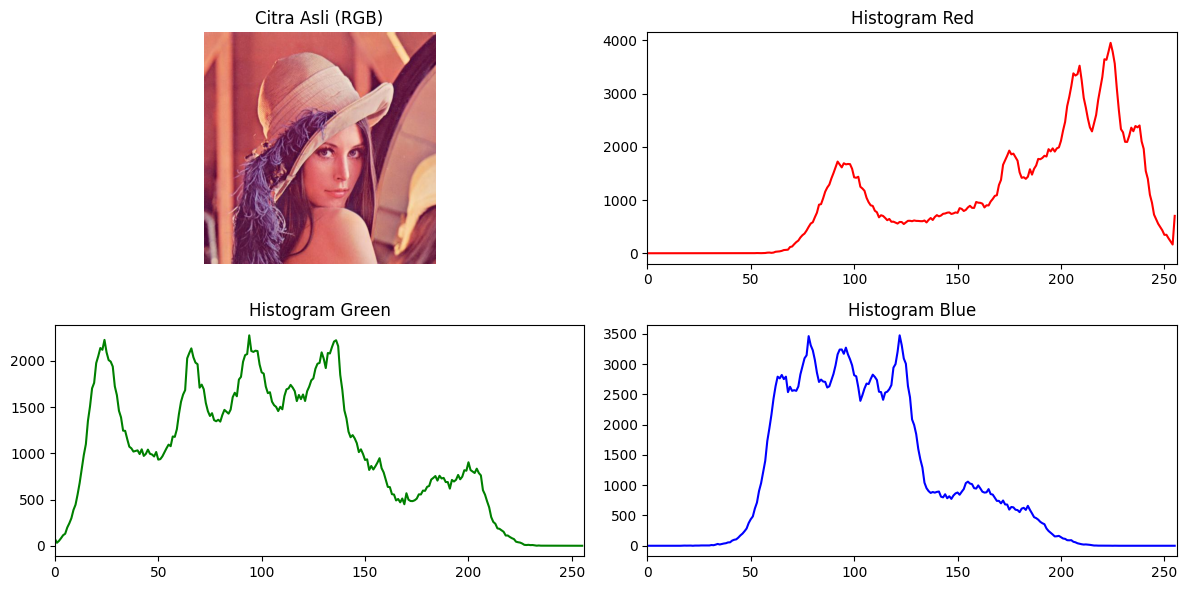

In [47]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Baca gambar (gambar yang dibaca, lena.jpg)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # ubah dari BGR ke RGB biar warnanya benar

# 2. Memisahkan channel warna
r, g, b = cv.split(img)

# 3. Hitung histogram masing-masing channel
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])

# 4. Tampilkan gambar asli dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Citra Asli (RGB)')
plt.axis('off')

plt.subplot(2,2,2)
plt.plot(hist_r, color='red')
plt.title('Histogram Red')
plt.xlim([0,256])

plt.subplot(2,2,3)
plt.plot(hist_g, color='green')
plt.title('Histogram Green')
plt.xlim([0,256])

plt.subplot(2,2,4)
plt.plot(hist_b, color='blue')
plt.title('Histogram Blue')
plt.xlim([0,256])

plt.tight_layout()
plt.show()


#**3. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

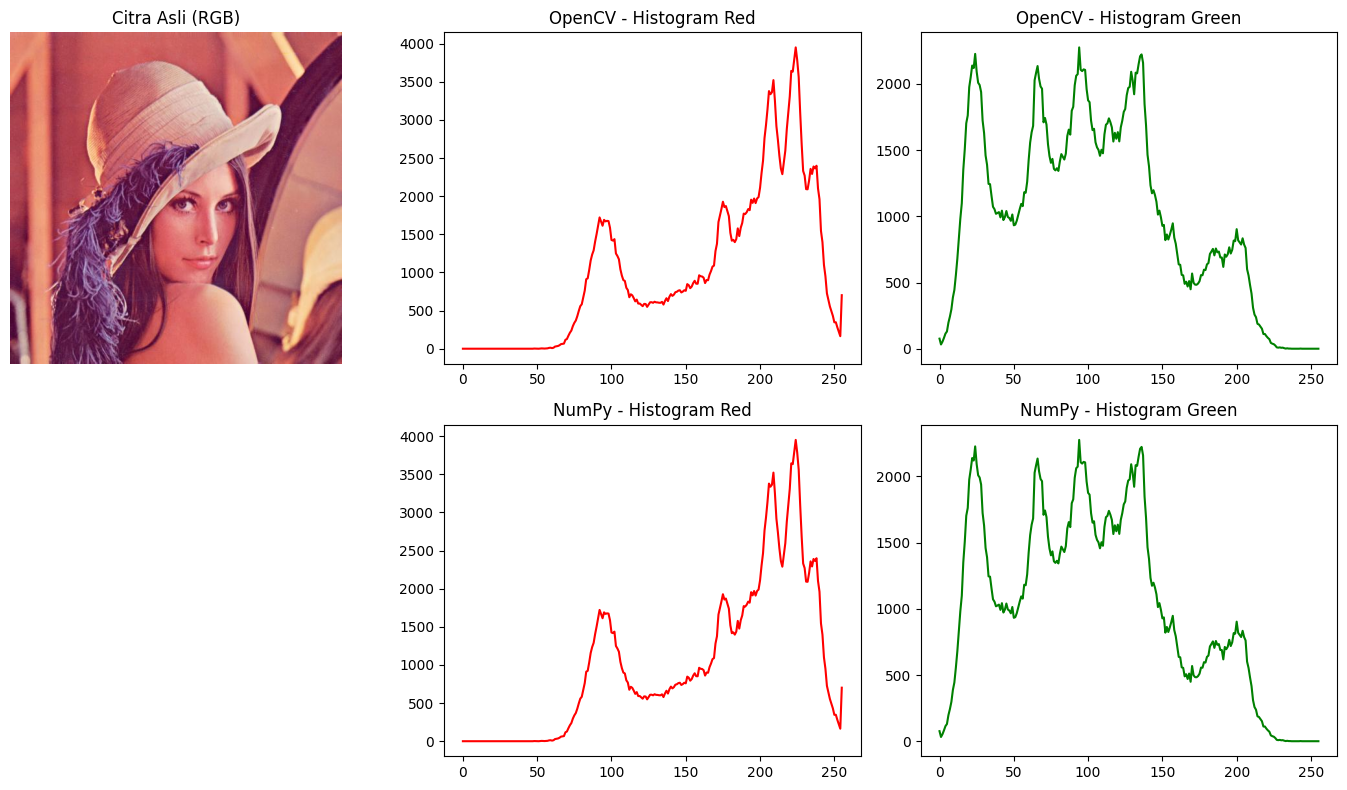

Apakah histogram Red sama?   → True
Apakah histogram Green sama? → True
Apakah histogram Blue sama?  → True


In [48]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar (contoh: lena.jpg)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2. Pisahkan channel warna
r, g, b = cv.split(img)

# 3. Hitung histogram dengan OpenCV
hist_r_cv = cv.calcHist([r], [0], None, [256], [0, 256])
hist_g_cv = cv.calcHist([g], [0], None, [256], [0, 256])
hist_b_cv = cv.calcHist([b], [0], None, [256], [0, 256])

# 4. Hitung histogram dengan NumPy
hist_r_np, bins_r = np.histogram(r, bins=256, range=(0,256))
hist_g_np, bins_g = np.histogram(g, bins=256, range=(0,256))
hist_b_np, bins_b = np.histogram(b, bins=256, range=(0,256))

# 5. Tampilkan hasil untuk perbandingan
plt.figure(figsize=(14,8))

# --- Hasil OpenCV ---
plt.subplot(2,3,1)
plt.imshow(img)
plt.title('Citra Asli (RGB)')
plt.axis('off')

plt.subplot(2,3,2)
plt.plot(hist_r_cv, color='red')
plt.title('OpenCV - Histogram Red')

plt.subplot(2,3,3)
plt.plot(hist_g_cv, color='green')
plt.title('OpenCV - Histogram Green')

# --- Hasil NumPy ---
plt.subplot(2,3,5)
plt.plot(hist_r_np, color='red')
plt.title('NumPy - Histogram Red')

plt.subplot(2,3,6)
plt.plot(hist_g_np, color='green')
plt.title('NumPy - Histogram Green')

plt.tight_layout()
plt.show()

# 6. Bandingkan kesamaan nilai histogram
same_r = np.allclose(hist_r_cv.flatten(), hist_r_np)
same_g = np.allclose(hist_g_cv.flatten(), hist_g_np)
same_b = np.allclose(hist_b_cv.flatten(), hist_b_np)

print("Apakah histogram Red sama?   →", same_r)
print("Apakah histogram Green sama? →", same_g)
print("Apakah histogram Blue sama?  →", same_b)


# **4. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

**HASIL ANALISA**

Secara numerik nilai histogram yang dihasilkan oleh kedua metode akan sama. Ini dikarenakan keduanya menghitung jumlah piksel dengan intensitas 0-255 untuk setiap warna. Namun ada sedikit perbedaan, yaitu dibagian bentuk output array dan tipe datanya.
* cv2.calcHist() dan,
* np.histogram().

# **5. Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)**

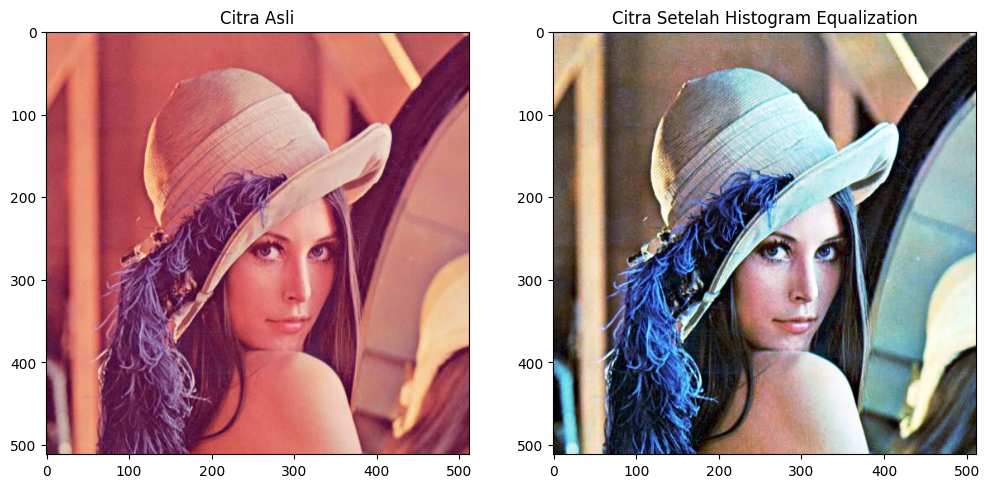

/tmp/ipython-input-4073356043.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_asli[i].ravel(), 256, [0,256], color=color)
/tmp/ipython-input-4073356043.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_eq[i].ravel(), 256, [0,256], color=color)


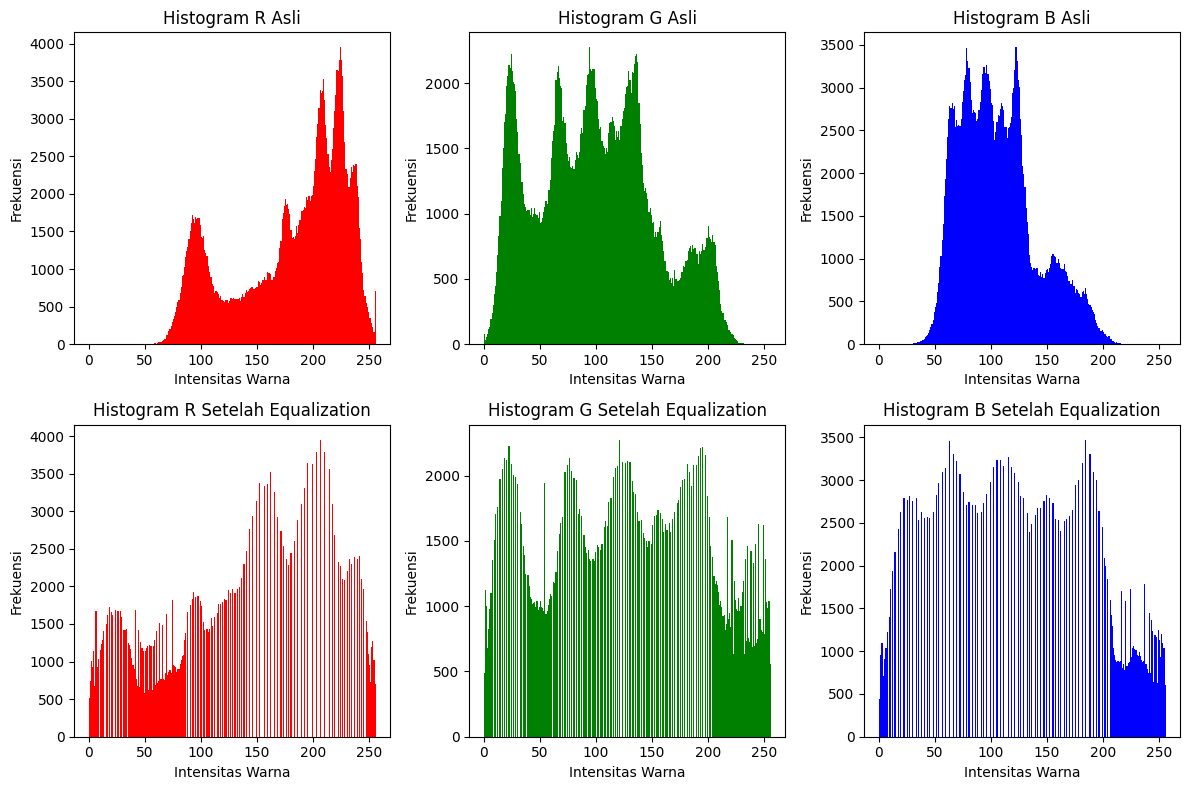

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar asli
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Pisahkan channel warna
r, g, b = cv2.split(img_rgb)

# Lakukan histogram equalization untuk setiap channel
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

# Gabungkan kembali channel yang sudah di-equalize
img_eq = cv2.merge((r_eq, g_eq, b_eq))

# Menampilkan gambar sebelum dan sesudah
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(img_eq)
plt.title('Citra Setelah Histogram Equalization')
plt.show()

# Menampilkan Histogram RGB sebelum dan sesudah
colors = ('r', 'g', 'b')
channels_asli = (r, g, b)
channels_eq = (r_eq, g_eq, b_eq)

plt.figure(figsize=(12, 8))
for i, color in enumerate(colors):
    plt.subplot(2, 3, i+1)
    plt.hist(channels_asli[i].ravel(), 256, [0,256], color=color)
    plt.title(f'Histogram {color.upper()} Asli')
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Frekuensi')

    plt.subplot(2, 3, i+4)
    plt.hist(channels_eq[i].ravel(), 256, [0,256], color=color)
    plt.title(f'Histogram {color.upper()} Setelah Equalization')
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Frekuensi')

# Tampilkan hasil
plt.tight_layout()
plt.show()


# **6. Setelah mengerjakan soal no. 5, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist Bandingkan hasilnya. Apakah output muncul sama?**

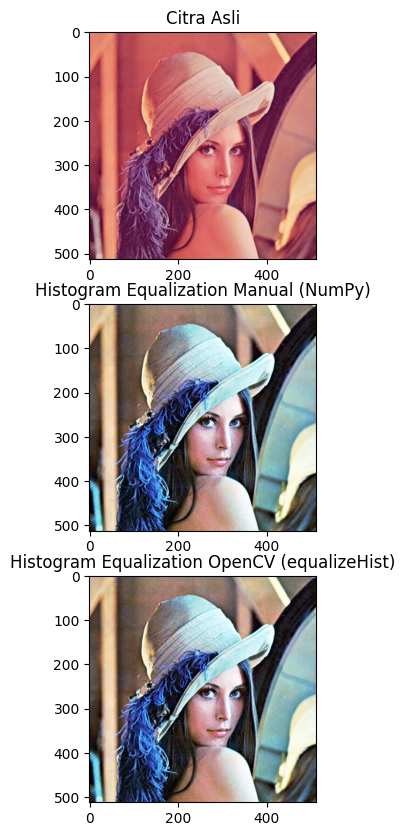

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Pisah channel
r, g, b = cv2.split(img_rgb)

# Histogram Equalization manual dengan NumPy
def manual_equalization(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf_final[channel]

r_manual = manual_equalization(r)
g_manual = manual_equalization(g)
b_manual = manual_equalization(b)
img_manual_eq = cv2.merge((r_manual, g_manual, b_manual))

# Histogram Equalization built-in OpenCV
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)
img_cv_eq = cv2.merge((r_eq, g_eq, b_eq))

# Menampilkan hasil perbandingan
plt.figure(figsize=(10, 10))
plt.subplot(3, 1, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")

plt.subplot(3, 1, 2)
plt.imshow(img_manual_eq)
plt.title("Histogram Equalization Manual (NumPy)")

plt.subplot(3, 1, 3)
plt.imshow(img_cv_eq)
plt.title("Histogram Equalization OpenCV (equalizeHist)")
plt.show()


**Hasil Analisa**

Output dari numpy dan OpenCV sangat mirip, tetapi karena keduanya menggunakan prinsip yang sama yaitu (CDF normalization) yang dimana perbedaannya mungkin kecil dikarenakan rounding dan konversi tipe data di tiap library.

# **7. Lakukanlah proses pemetaan 16 juta warna RGB ke dalam 8 warna saja, yaitu hitam, hijau, kuning, biru, cyan, magenta, putih seperti output berikut berdasarkan flowchart di bawah ini! (Gunakan gambar lena jpg)**

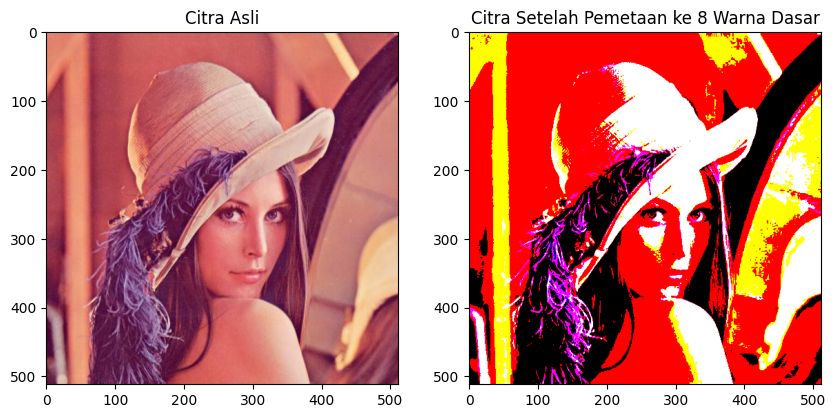

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalisasi nilai warna ke 0–1
img_norm = img_rgb / 255.0

# Tentukan ambang batas (threshold)
# Jika > 0.5 maka dianggap 1 (nyala), jika <= 0.5 dianggap 0 (mati)
img_bin = (img_norm > 0.5).astype(np.uint8)

# Konversi kembali ke 0 atau 255 (8 warna dasar)
img_8color = img_bin * 255

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Asli")

plt.subplot(1,2,2)
plt.imshow(img_8color)
plt.title("Citra Setelah Pemetaan ke 8 Warna Dasar")
plt.show()

# **8. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman modul ini! (Gunakan gambar lena.jpg)**

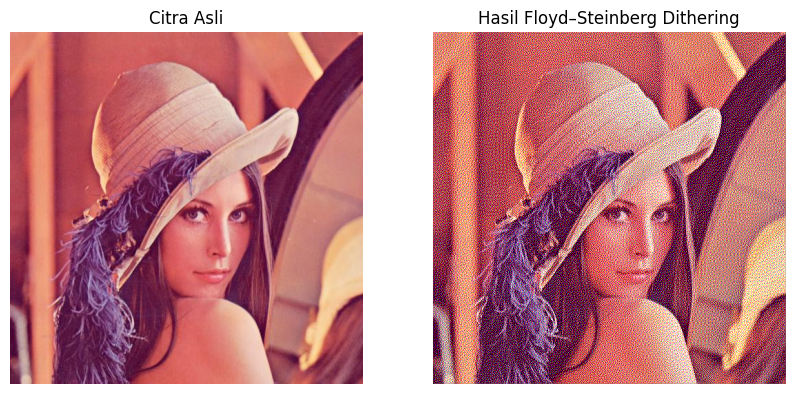

In [52]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Membaca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2️⃣ Siapkan array hasil dithering dengan tipe float agar tidak overflow
dithered = np.copy(img_rgb).astype(float)

# 3️⃣ Proses Floyd–Steinberg untuk setiap channel warna (R, G, B)
h, w, c = dithered.shape
for y in range(h - 1):
    for x in range(1, w - 1):
        for ch in range(3):  # tiap channel warna
            old_pixel = dithered[y, x, ch]
            new_pixel = 255 if old_pixel > 128 else 0
            dithered[y, x, ch] = new_pixel
            quant_error = old_pixel - new_pixel

            # Sebarkan error ke piksel tetangga
            dithered[y, x + 1, ch]     += quant_error * 7 / 16
            dithered[y + 1, x - 1, ch] += quant_error * 3 / 16
            dithered[y + 1, x, ch]     += quant_error * 5 / 16
            dithered[y + 1, x + 1, ch] += quant_error * 1 / 16

# Pastikan nilai piksel valid
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dithered)
plt.title('Hasil Floyd–Steinberg Dithering')
plt.axis('off')

plt.show()


# **9. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga menampilkan gambar di bawah ini!**

/tmp/ipython-input-472182416.py:53: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256], color='gray')
/tmp/ipython-input-472182416.py:57: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0, 256], color='gray')


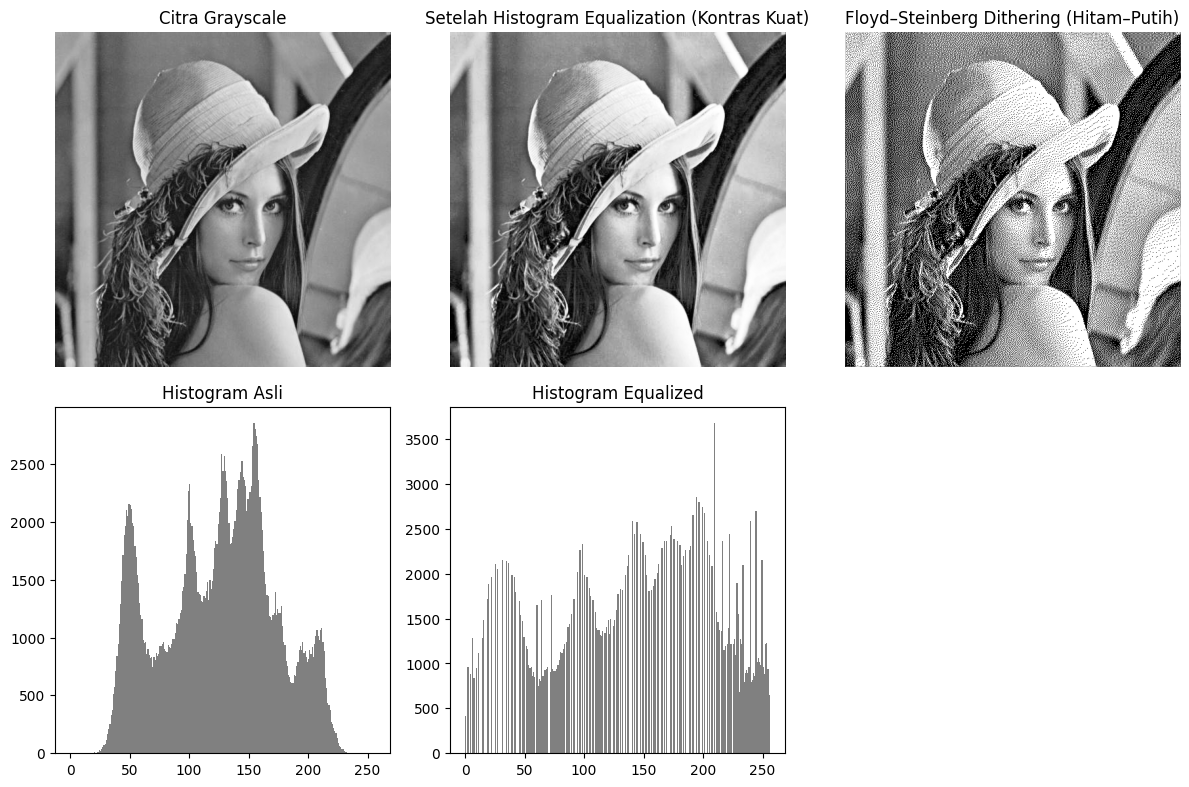

In [53]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.result.jpg')

# 2️⃣ Ubah menjadi grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 3️⃣ Histogram Equalization untuk meningkatkan kontras
equalized = cv.equalizeHist(gray)

# 4️⃣ Tingkatkan kontras lagi (opsional)
# Membuat efek mirip gamma correction agar citra makin tegas
gamma = 1.2  #
equalized = np.clip((equalized / 255.0) ** (1 / gamma) * 255, 0, 255).astype(np.uint8)

# 5️⃣ Implementasi Floyd–Steinberg Dithering
def floyd_steinberg_dither(image):
    img = image.astype(float) / 255.0
    h, w = img.shape
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = img[y, x]
            new_pixel = 1 if old_pixel > 0.5 else 0  # biner kuat, hitam-putih jelas
            img[y, x] = new_pixel
            error = old_pixel - new_pixel
            img[y, x + 1] += error * 7 / 16
            img[y + 1, x - 1] += error * 3 / 16
            img[y + 1, x] += error * 5 / 16
            img[y + 1, x + 1] += error * 1 / 16
    return (img * 255).astype(np.uint8)

dithered = floyd_steinberg_dither(equalized)

# 6️⃣ Tampilkan hasil
plt.figure(figsize=(12, 8))

# Gambar sebelum dan sesudah equalization
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Grayscale')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(equalized, cmap='gray')
plt.title('Setelah Histogram Equalization (Kontras Kuat)')
plt.axis('off')

# Histogram
plt.subplot(2, 3, 4)
plt.hist(gray.ravel(), 256, [0, 256], color='gray')
plt.title('Histogram Asli')

plt.subplot(2, 3, 5)
plt.hist(equalized.ravel(), 256, [0, 256], color='gray')
plt.title('Histogram Equalized')

# Hasil dithering
plt.subplot(2, 3, 3)
plt.imshow(dithered, cmap='gray')
plt.title('Floyd–Steinberg Dithering (Hitam–Putih)')
plt.axis('off')

plt.tight_layout()
plt.show()
